In [1]:
import pandas as pd

df = pd.read_csv("household_power_consumption.csv", sep=',')

In [2]:
df['Datetime'] = pd.to_datetime(df['Date'] + ' ' + df['Time'], dayfirst=True)

df = df.set_index('Datetime')

In [3]:
df = df.replace('?', pd.NA)

numeric_cols = [
'Global_active_power',
'Global_reactive_power',
'Voltage',
'Global_intensity',
'Sub_metering_1',
'Sub_metering_2',
'Sub_metering_3'
]

df[numeric_cols] = df[numeric_cols].astype(float)

In [4]:
print(df.head())

print(df.info())

                           Date      Time  Global_active_power  \
Datetime                                                         
2006-12-16 17:24:00  16/12/2006  17:24:00                4.216   
2006-12-16 17:25:00  16/12/2006  17:25:00                5.360   
2006-12-16 17:26:00  16/12/2006  17:26:00                5.374   
2006-12-16 17:27:00  16/12/2006  17:27:00                5.388   
2006-12-16 17:28:00  16/12/2006  17:28:00                3.666   

                     Global_reactive_power  Voltage  Global_intensity  \
Datetime                                                                
2006-12-16 17:24:00                  0.418   234.84              18.4   
2006-12-16 17:25:00                  0.436   233.63              23.0   
2006-12-16 17:26:00                  0.498   233.29              23.0   
2006-12-16 17:27:00                  0.502   233.74              23.0   
2006-12-16 17:28:00                  0.528   235.68              15.8   

                     Sub_

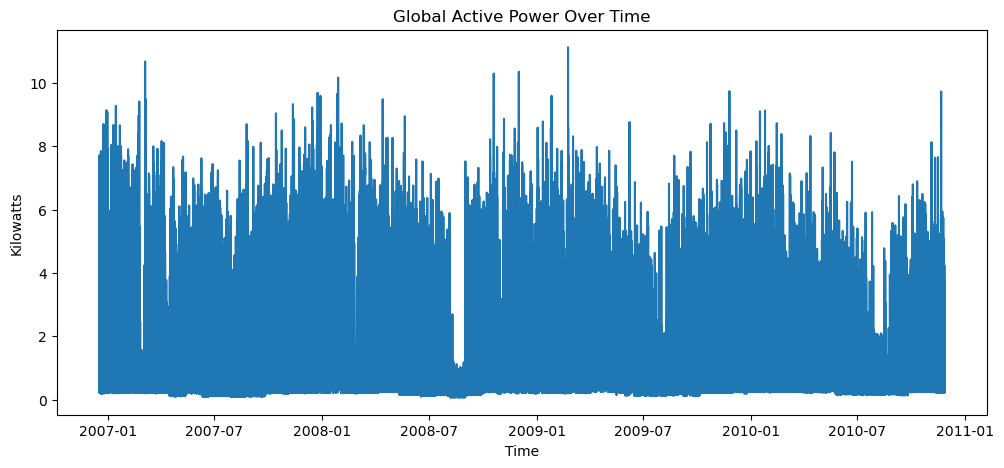

In [5]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(df.index, df['Global_active_power'])

plt.title("Global Active Power Over Time")
plt.xlabel("Time")
plt.ylabel("Kilowatts")

plt.show()

In [9]:
print(df.isnull().sum())

Date                     0
Time                     0
Global_active_power      0
Global_reactive_power    0
Voltage                  0
Global_intensity         0
Sub_metering_1           0
Sub_metering_2           0
Sub_metering_3           0
dtype: int64


In [8]:
df = df.dropna()

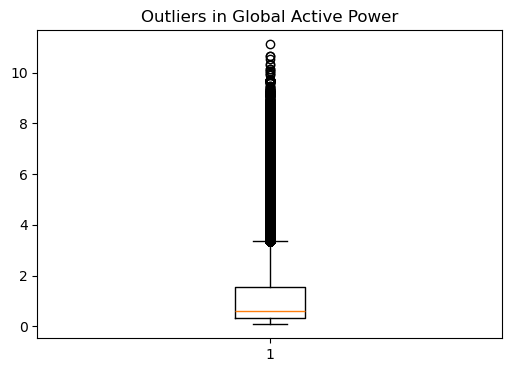

In [10]:
plt.figure(figsize=(6,4))

plt.boxplot(df['Global_active_power'])

plt.title("Outliers in Global Active Power")

plt.show()

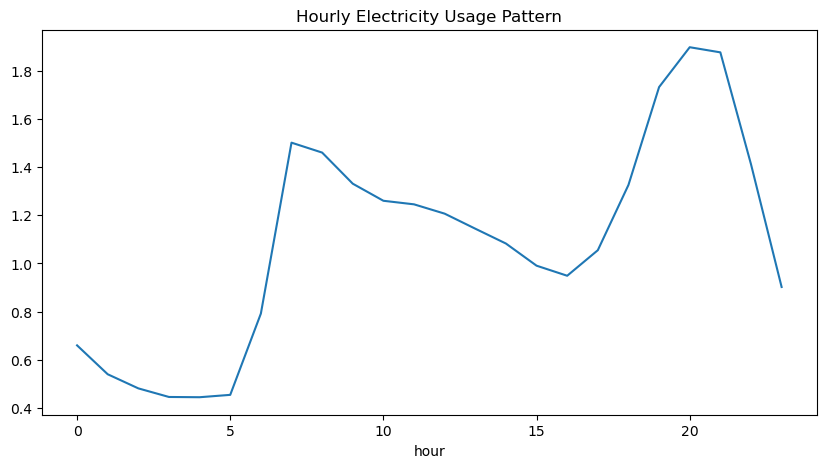

In [11]:
df['hour'] = df.index.hour

hourly_avg = df.groupby('hour')['Global_active_power'].mean()

hourly_avg.plot(figsize=(10,5))

plt.title("Hourly Electricity Usage Pattern")

plt.show()

In [13]:
df_hourly = df.select_dtypes(include='number').resample('H').mean()

print(df_hourly.head())

                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 17:00:00             4.222889               0.229000  234.643889   
2006-12-16 18:00:00             3.632200               0.080033  234.580167   
2006-12-16 19:00:00             3.400233               0.085233  233.232500   
2006-12-16 20:00:00             3.268567               0.075100  234.071500   
2006-12-16 21:00:00             3.056467               0.076667  237.158667   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 17:00:00         18.100000             0.0        0.527778   
2006-12-16 18:00:00         15.600000             0.0        6.716667   
2006-12-16 19:00:00         14.503333             0.0        1.433333   
2006-12-16 20:00:00         13.916667             0.0        0.000000   
2006-12-

In [16]:
target = 'Global_active_power'

lags = 3

for i in range(1, lags+1):
    df_hourly[f'lag_{i}'] = df_hourly[target].shift(i)

df_hourly = df_hourly.dropna()

print(df_hourly.head())

                     Global_active_power  Global_reactive_power     Voltage  \
Datetime                                                                      
2006-12-16 23:00:00             2.061600               0.071433  240.619667   
2006-12-17 00:00:00             1.882467               0.102433  240.961833   
2006-12-17 01:00:00             3.349400               0.136933  240.448333   
2006-12-17 02:00:00             1.587267               0.078233  245.818667   
2006-12-17 03:00:00             1.662200               0.079533  244.513500   

                     Global_intensity  Sub_metering_1  Sub_metering_2  \
Datetime                                                                
2006-12-16 23:00:00          8.896667             0.0        0.083333   
2006-12-17 00:00:00          8.126667             0.0        0.466667   
2006-12-17 01:00:00         14.246667             0.0       25.233333   
2006-12-17 02:00:00          6.870000             0.0        0.566667   
2006-12-

In [17]:
train_size = int(len(df_hourly)*0.8)

train = df_hourly[:train_size]
test = df_hourly[train_size:]

X_train = train[['lag_1','lag_2','lag_3']]
y_train = train[target]

X_test = test[['lag_1','lag_2','lag_3']]
y_test = test[target]

In [53]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()

model.fit(X_train, y_train)

LinearRegression()

In [54]:
predictions = model.predict(X_test)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

mae = mean_absolute_error(y_test, predictions)

rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("MAE:", mae)
print("RMSE:", rmse)

MAE: 0.4026339102164776
RMSE: 0.5517669605052543


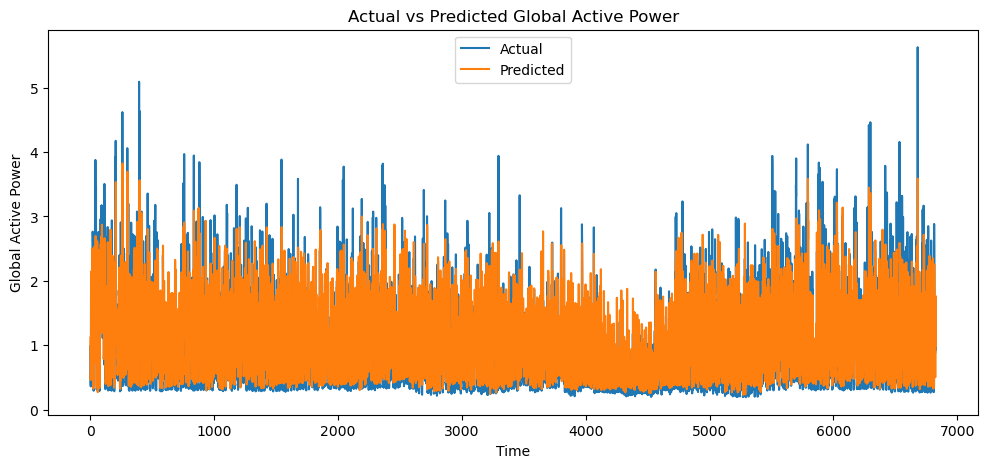

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(y_test.values, label='Actual')

plt.plot(predictions, label='Predicted')

plt.legend()

plt.title("Actual vs Predicted Global Active Power")

plt.xlabel("Time")

plt.ylabel("Global Active Power")

plt.show()

In [30]:
df_daily = df_hourly.resample('D').sum()

print(df_daily.head())

            Global_active_power  Global_reactive_power      Voltage  \
Datetime                                                              
2006-12-16             2.061600               0.071433   240.619667   
2006-12-17            56.507667               3.766767  5762.088667   
2006-12-18            36.730433               2.696533  5789.560667   
2006-12-19            27.769900               2.515700  5807.983500   
2006-12-20            37.095800               2.683300  5815.393500   

            Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
Datetime                                                                       
2006-12-16          8.896667        0.000000        0.083333        0.000000   
2006-12-17        239.976667       33.883333       69.783333      222.350000   
2006-12-18        154.120000       17.716667       43.683333      233.633333   
2006-12-19        118.233333       13.983333      126.700000      103.283333   
2006-12-20        155.

In [31]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    contamination=0.05,   # 5% unusual days
    random_state=42
)

df_daily['anomaly'] = model.fit_predict(
    df_daily[['Global_active_power']]
)

print(df_daily.head())

            Global_active_power  Global_reactive_power      Voltage  \
Datetime                                                              
2006-12-16             2.061600               0.071433   240.619667   
2006-12-17            56.507667               3.766767  5762.088667   
2006-12-18            36.730433               2.696533  5789.560667   
2006-12-19            27.769900               2.515700  5807.983500   
2006-12-20            37.095800               2.683300  5815.393500   

            Global_intensity  Sub_metering_1  Sub_metering_2  Sub_metering_3  \
Datetime                                                                       
2006-12-16          8.896667        0.000000        0.083333        0.000000   
2006-12-17        239.976667       33.883333       69.783333      222.350000   
2006-12-18        154.120000       17.716667       43.683333      233.633333   
2006-12-19        118.233333       13.983333      126.700000      103.283333   
2006-12-20        155.

/userhome/jp/anaconda3/lib/python3.11/site-packages/sklearn/base.py:439: UserWarning: X does not have valid feature names, but IsolationForest was fitted with feature names
  warnings.warn(


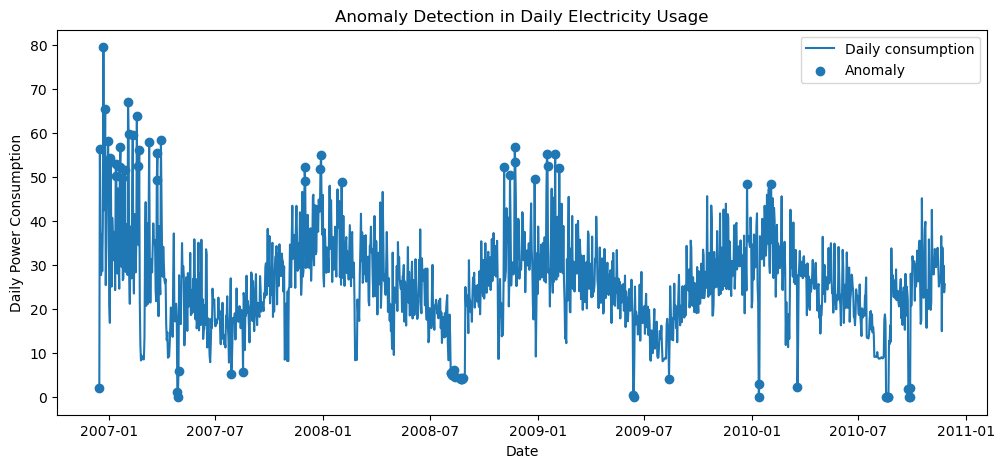

In [32]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

plt.plot(
    df_daily.index,
    df_daily['Global_active_power'],
    label='Daily consumption'
)

anomalies = df_daily[df_daily['anomaly'] == -1]

plt.scatter(
    anomalies.index,
    anomalies['Global_active_power'],
    label='Anomaly'
)

plt.legend()

plt.title("Anomaly Detection in Daily Electricity Usage")

plt.xlabel("Date")

plt.ylabel("Daily Power Consumption")

plt.show()

In [37]:
daily_profile = df_hourly.copy()

daily_profile['date'] = daily_profile.index.date

daily_profile['hour'] = daily_profile.index.hour

pivot = daily_profile.pivot_table(
    values='Global_active_power',
    index='date',
    columns='hour'
)

pivot = pivot.dropna()

print(pivot.shape)

(1417, 24)


In [38]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=3,
    random_state=42
)

pivot['cluster'] = kmeans.fit_predict(pivot)

print(pivot.head())

hour               0         1         2         3         4         5  \
date                                                                     
2006-12-17  1.882467  3.349400  1.587267  1.662200  2.215767  1.996733   
2006-12-18  0.276367  0.313300  0.284467  0.309933  1.026333  0.293500   
2006-12-19  0.837133  0.353033  0.327233  0.308300  0.327833  0.306667   
2006-12-20  0.459833  0.258667  0.784367  0.310033  0.289000  0.262700   
2006-12-21  1.535867  1.397967  1.274900  0.302600  0.246733  0.290700   

hour               6         7         8         9  ...        15        16  \
date                                                ...                       
2006-12-17  1.303300  1.620033  1.890567  2.549067  ...  2.985400  3.326033   
2006-12-18  0.610000  2.450433  2.082133  1.629333  ...  1.784300  1.949300   
2006-12-19  0.796333  1.785633  3.879033  1.617767  ...  0.421367  1.372133   
2006-12-20  0.283600  1.526633  2.917600  1.385533  ...  0.281133  0.468433   
2006-12

/userhome/jp/anaconda3/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:870: FutureWarning: The default value of `n_init` will change from 10 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  warnings.warn(


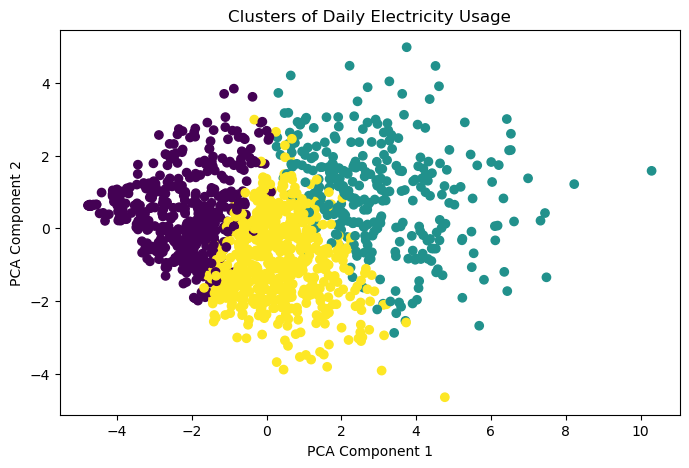

In [39]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)

reduced = pca.fit_transform(
    pivot.drop('cluster', axis=1)
)

plt.figure(figsize=(8,5))

plt.scatter(
    reduced[:,0],
    reduced[:,1],
    c=pivot['cluster']
)

plt.title("Clusters of Daily Electricity Usage")

plt.xlabel("PCA Component 1")

plt.ylabel("PCA Component 2")

plt.show()

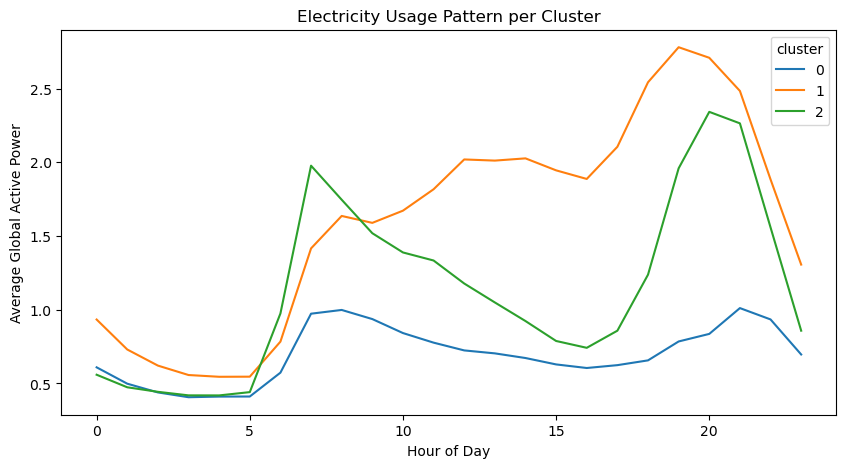

In [42]:
cluster_summary = pivot.groupby('cluster').mean()

cluster_summary.T.plot(figsize=(10,5))

plt.title("Electricity Usage Pattern per Cluster")

plt.xlabel("Hour of Day")

plt.ylabel("Average Global Active Power")

plt.show()

In [43]:
def usage_category(power):

    if power < 1:
        category = "Low Usage"
        suggestion = "Energy usage is efficient. Maintain current consumption habits."

    elif power < 2:
        category = "Medium Usage"
        suggestion = "Try turning off unused appliances to reduce electricity consumption."

    else:
        category = "High Usage"
        suggestion = "High electricity usage detected. Consider reducing air conditioning or heavy appliance use."

    return category, suggestion

In [44]:
example_value = predictions[0]

category, suggestion = usage_category(example_value)

print("Predicted Power:", example_value)

print("Usage Category:", category)

print("Suggestion:", suggestion)

Predicted Power: 1.4188590995508772
Usage Category: Medium Usage
Suggestion: Try turning off unused appliances to reduce electricity consumption.


In [45]:
results = []

for p in predictions[:5]:

    category, suggestion = usage_category(p)

    results.append((p, category, suggestion))

for r in results:

    print("Power:", round(r[0],2),
          "| Category:", r[1],
          "| Suggestion:", r[2])

Power: 1.42 | Category: Medium Usage | Suggestion: Try turning off unused appliances to reduce electricity consumption.
Power: 0.96 | Category: Low Usage | Suggestion: Energy usage is efficient. Maintain current consumption habits.
Power: 0.55 | Category: Low Usage | Suggestion: Energy usage is efficient. Maintain current consumption habits.
Power: 0.59 | Category: Low Usage | Suggestion: Energy usage is efficient. Maintain current consumption habits.
Power: 0.6 | Category: Low Usage | Suggestion: Energy usage is efficient. Maintain current consumption habits.


In [55]:
import pickle

# save Linear Regression model
with open("linear_regression_power_model.pkl", "wb") as file:
    pickle.dump(model, file)

print("Linear Regression model saved successfully!")

Linear Regression model saved successfully!


In [56]:
print(type(model))

<class 'sklearn.linear_model._base.LinearRegression'>
